In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('final_project_dataset_complete.csv')
df.info()
print(df.describe())
print(df.head(20))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_1   9000 non-null   float64
 1   feature_2   9000 non-null   float64
 2   feature_3   8600 non-null   float64
 3   feature_4   9000 non-null   float64
 4   feature_5   9000 non-null   float64
 5   feature_6   8500 non-null   float64
 6   feature_7   9000 non-null   float64
 7   feature_8   9000 non-null   float64
 8   category_1  9000 non-null   object 
 9   category_2  9000 non-null   object 
 10  target      9000 non-null   int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 773.6+ KB
         feature_1    feature_2    feature_3    feature_4    feature_5  \
count  9000.000000  9000.000000  8600.000000  9000.000000  9000.000000   
mean      0.000427     0.003349     0.003235    -0.008481    -0.002177   
std       1.241318     2.508324     1.542901     2.061784     0.577415   


# Histogram Box plot

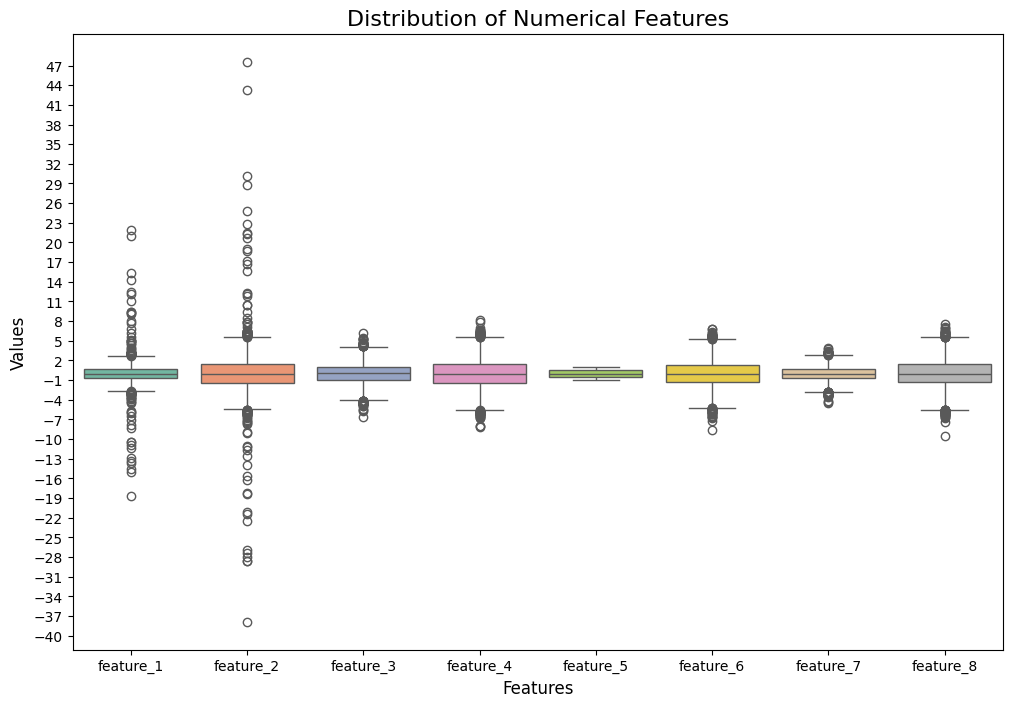

In [6]:
# List of numerical features
numerical_features = ['feature_1', 'feature_2', 'feature_3', 'feature_4',
                      'feature_5', 'feature_6', 'feature_7', 'feature_8']

# Create a boxplot for all numerical features
plt.figure(figsize=(12, 8))  # Set the figure size
sns.boxplot(data=df[numerical_features], palette="Set2")

# Add title and axis labels
plt.title("Distribution of Numerical Features", fontsize=16)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Values", fontsize=12)
plt.yticks(range(-40, 50, 3))
# Display the plot
plt.show()

<class 'pandas.core.frame.DataFrame'>


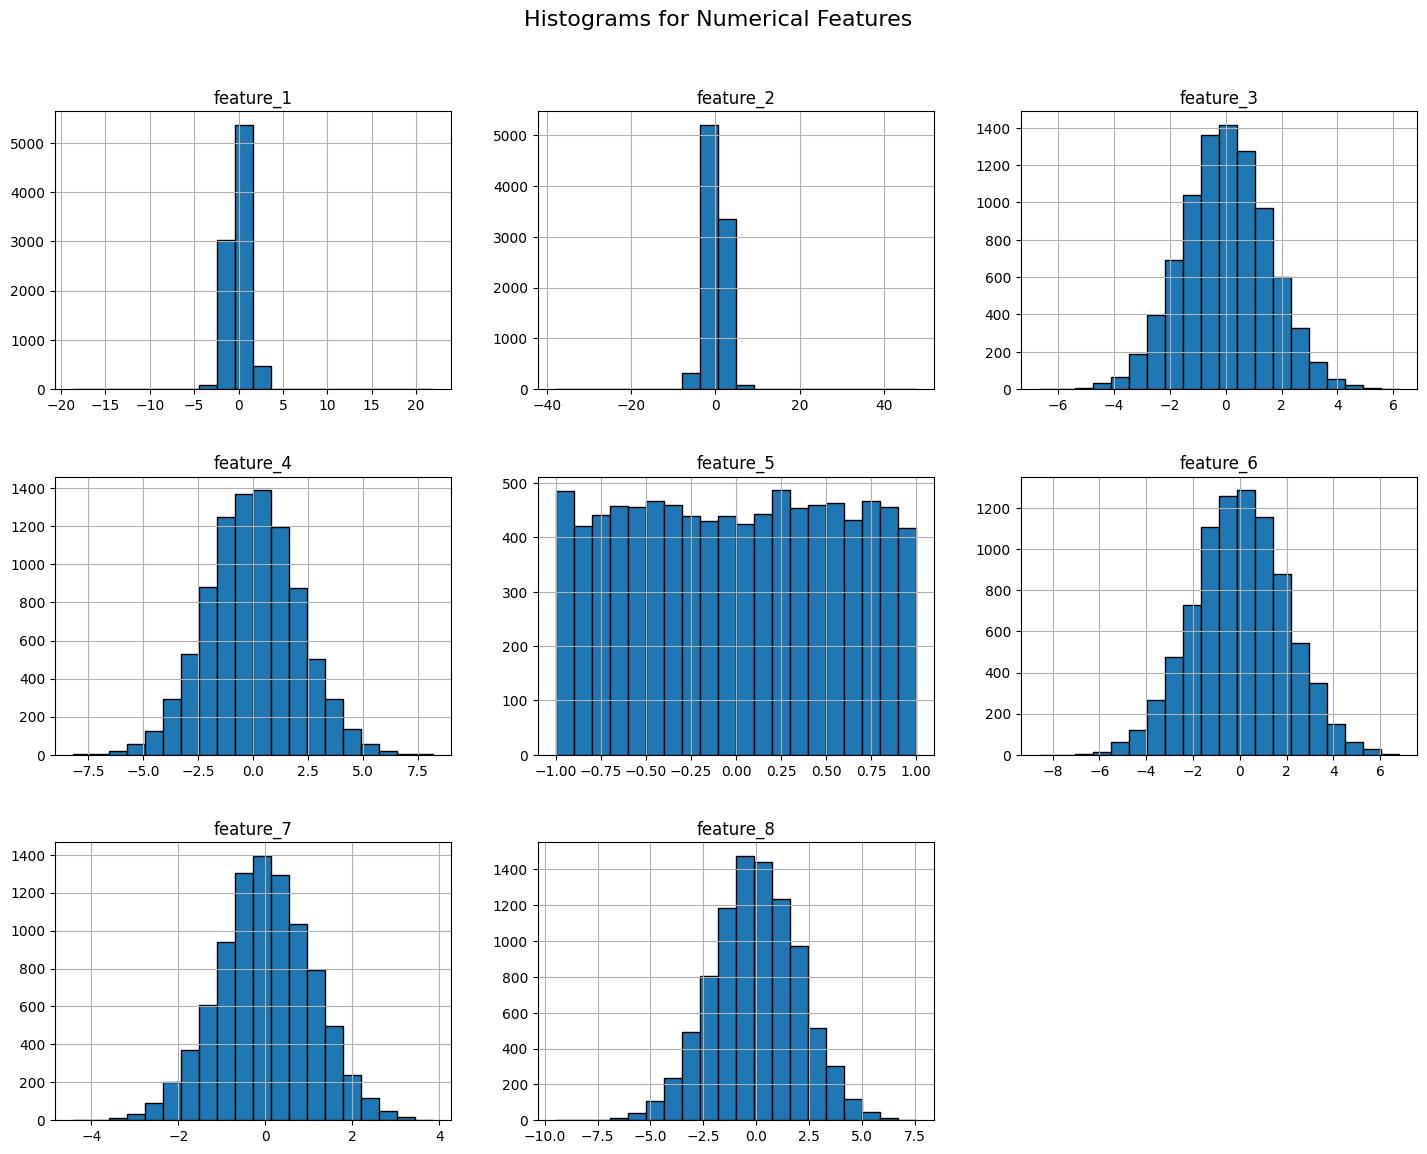

In [7]:
numerical_features = df.select_dtypes(include=['float64'])
print(type(numerical_features))
numerical_features.hist(figsize=(15, 12), bins=20, edgecolor='black')
plt.suptitle('Histograms for Numerical Features', fontsize=16)
plt.tight_layout(pad=3.0)

plt.show()

In [47]:
df_corrolation_matrix = df
df_corrolation_matrix = df_corrolation_matrix.drop(['category_1', 'category_2'], axis=1)
correlation_matrix = df_corrolation_matrix.corr()
correlation_matrix


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
feature_1,1.000000,0.995360,-0.831705,0.831922,-0.015305,-0.010813,-0.010843,-0.004581,0.605940
feature_2,0.995360,1.000000,-0.823242,0.832002,-0.014715,-0.011519,-0.011393,-0.005394,0.606016
feature_3,-0.831705,-0.823242,1.000000,-0.957222,0.011309,0.003989,0.006042,0.001846,-0.704351
feature_4,0.831922,0.832002,-0.957222,1.000000,-0.003613,-0.000213,-0.001369,0.001202,0.694885
feature_5,-0.015305,-0.014715,0.011309,-0.003613,1.000000,-0.009365,0.252371,-0.012717,-0.007873
feature_6,-0.010813,-0.011519,0.003989,-0.000213,-0.009365,1.000000,0.921569,0.969998,0.001457
feature_7,-0.010843,-0.011393,0.006042,-0.001369,0.252371,0.921569,1.000000,0.894220,-0.002000
feature_8,-0.004581,-0.005394,0.001846,0.001202,-0.012717,0.969998,0.894220,1.000000,0.004658
target,0.605940,0.606016,-0.704351,0.694885,-0.007873,0.001457,-0.002000,0.004658,1.000000


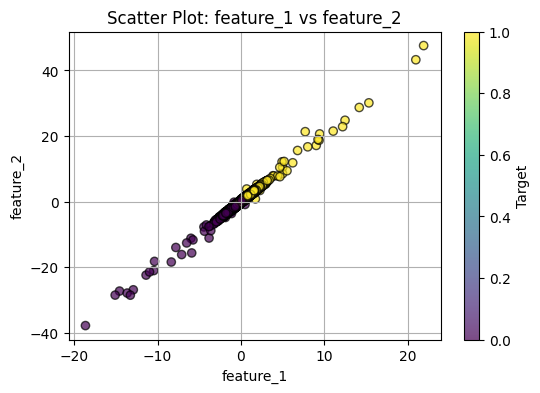

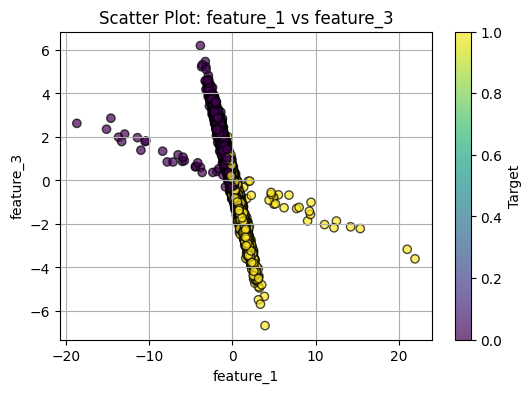

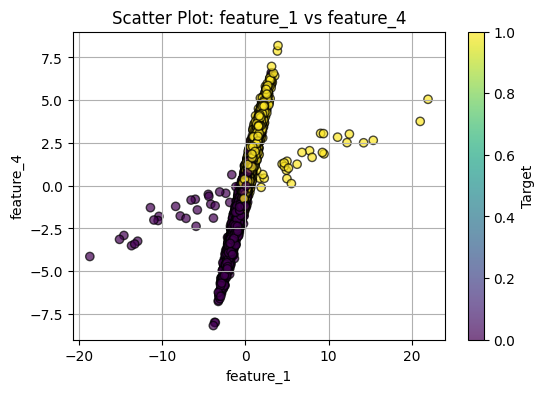

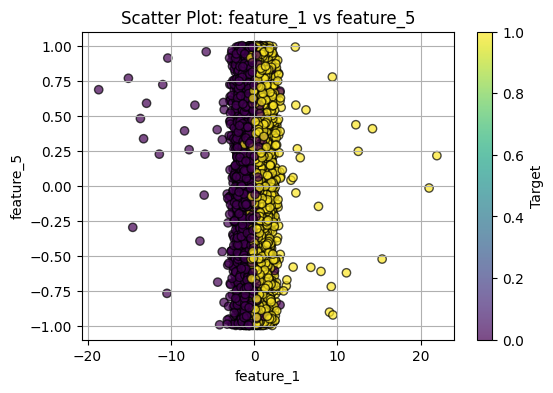

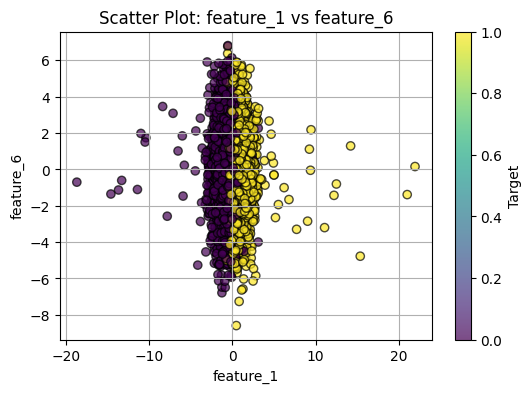

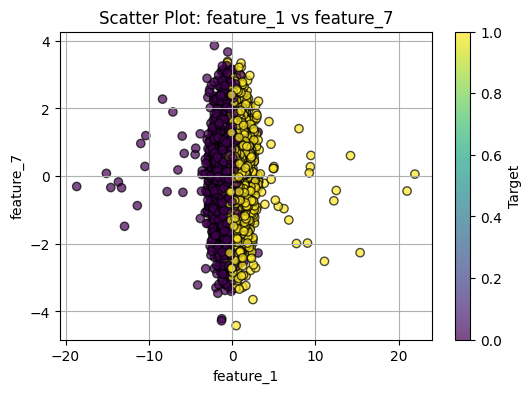

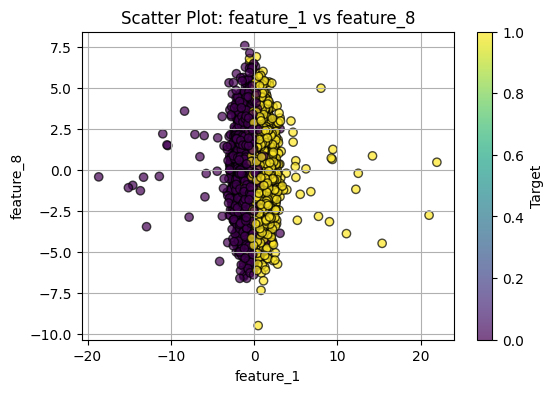

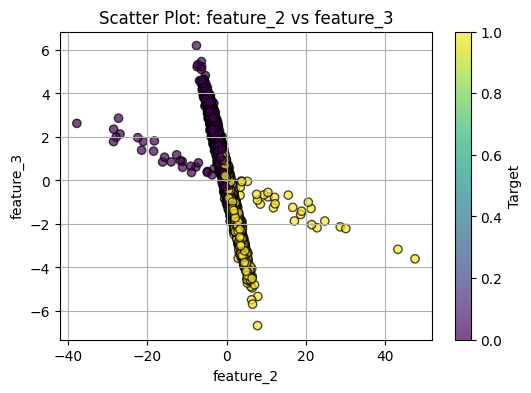

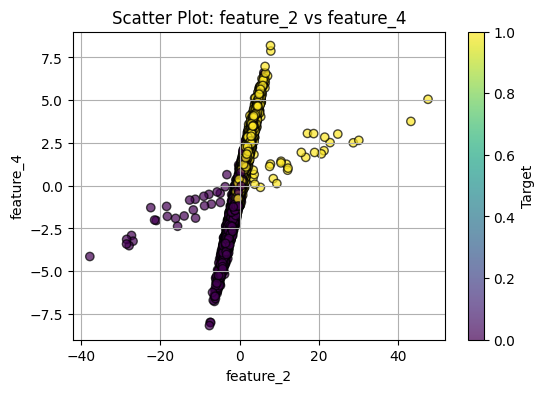

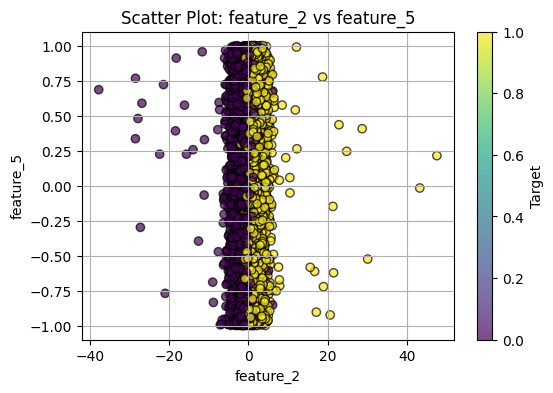

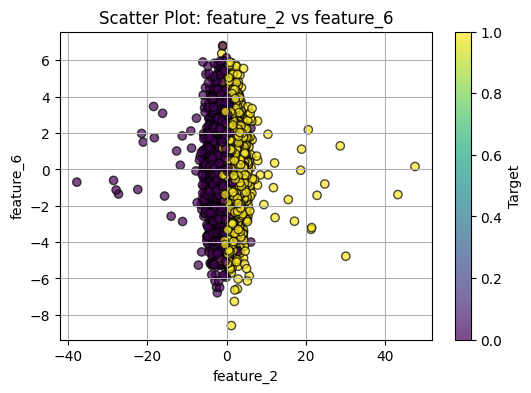

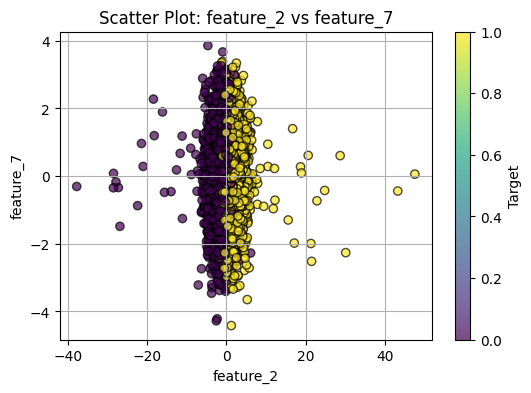

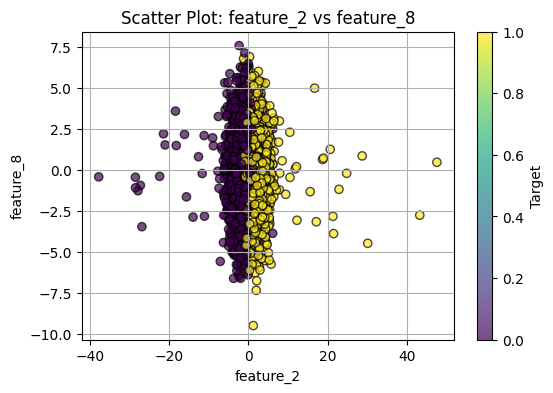

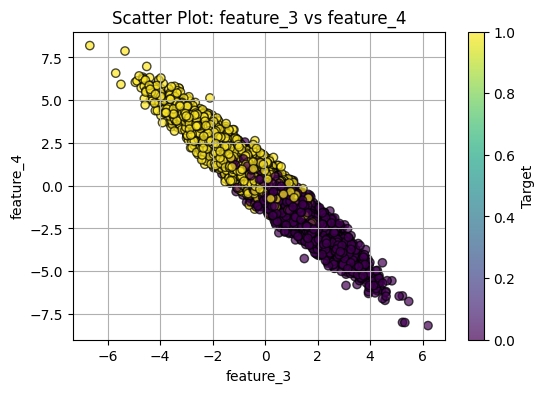

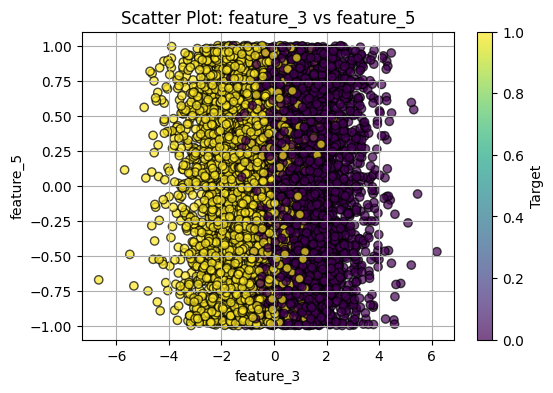

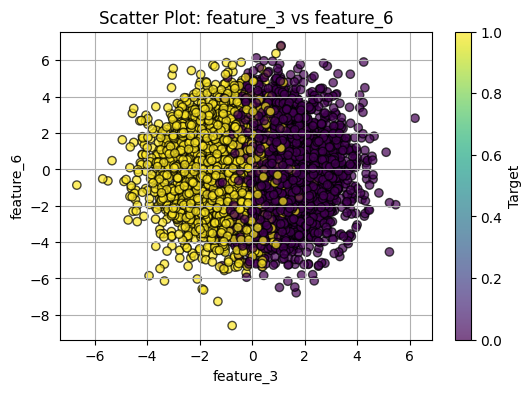

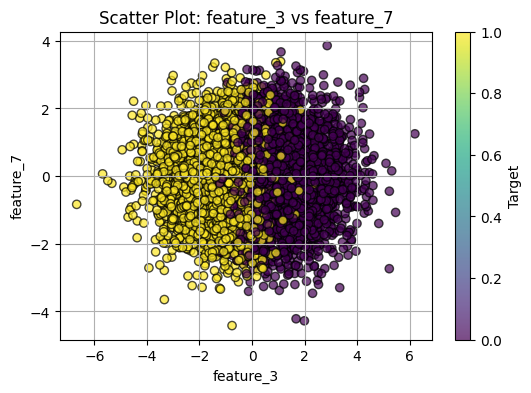

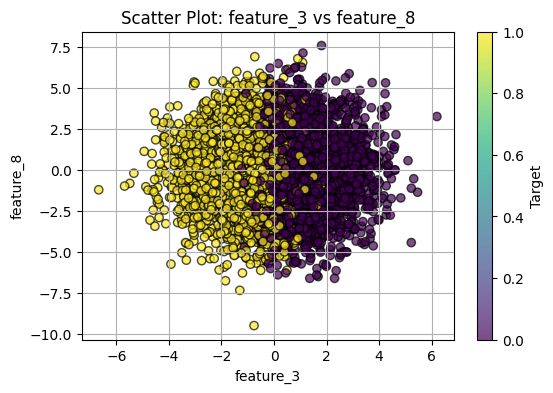

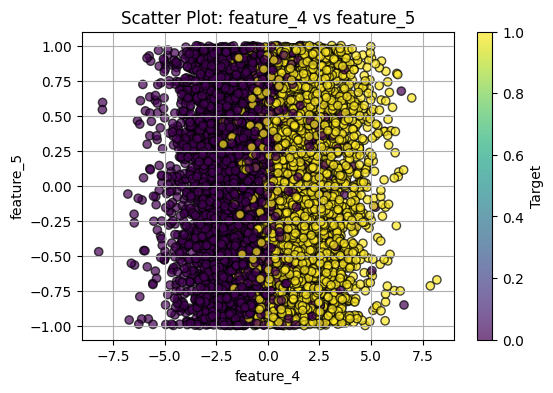

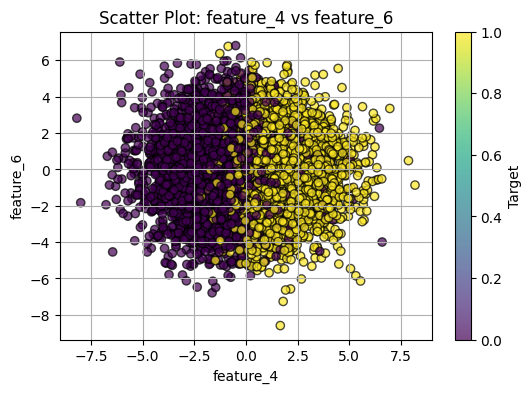

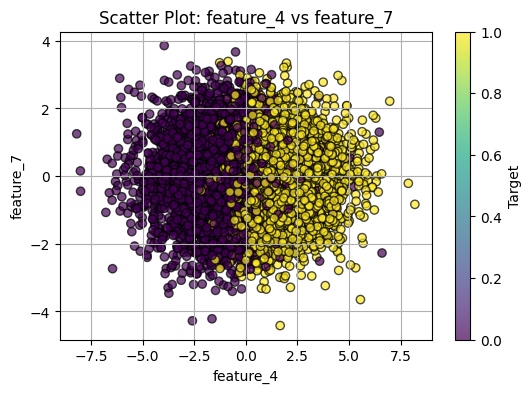

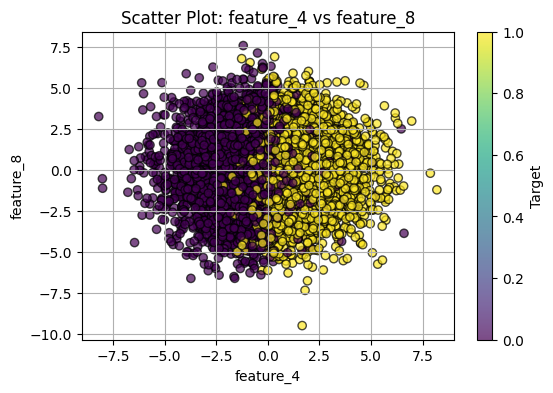

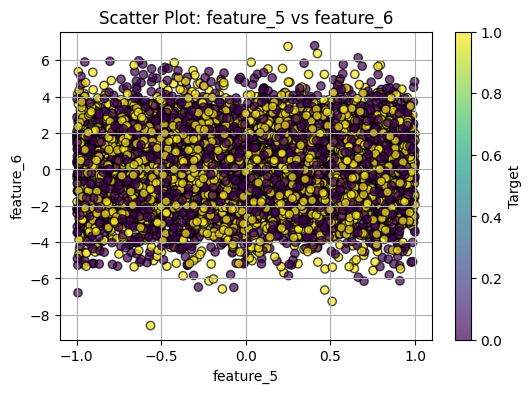

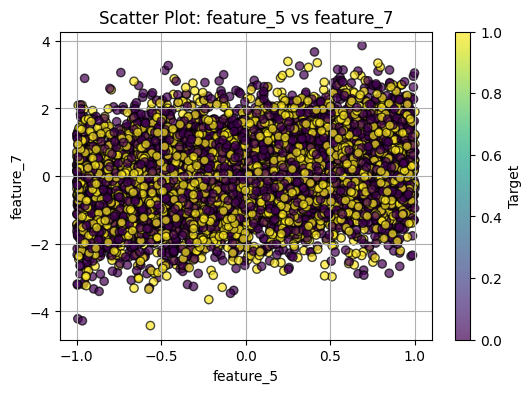

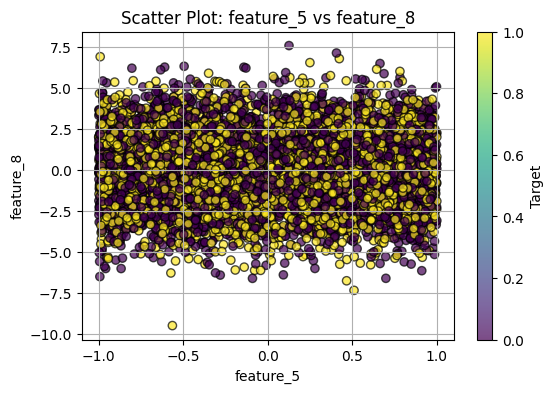

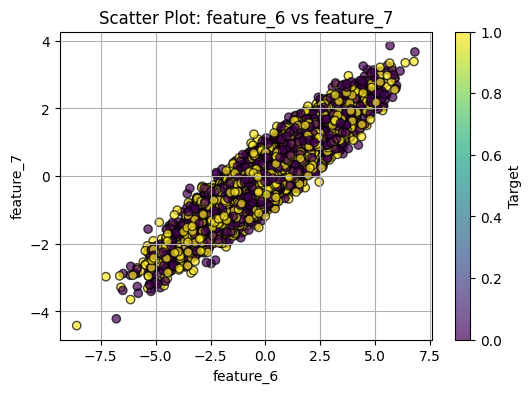

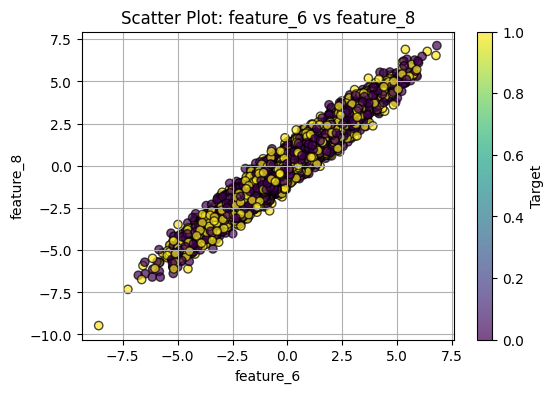

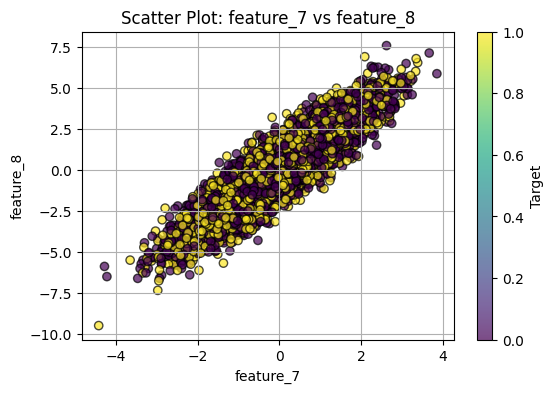

In [8]:
# Creating scatter plots for each pair of numerical features
numerical_features = [col for col in df.columns if col.startswith('feature')]

for i in range(len(numerical_features)):
    for j in range(i + 1, len(numerical_features)):
        plt.figure(figsize=(6, 4))
        plt.scatter(df[numerical_features[i]], df[numerical_features[j]], c=df['target'], cmap='viridis', edgecolor='k', alpha=0.7)
        plt.title(f"Scatter Plot: {numerical_features[i]} vs {numerical_features[j]}")
        plt.xlabel(numerical_features[i])
        plt.ylabel(numerical_features[j])
        plt.colorbar(label='Target')
        plt.grid(True)
        plt.show()

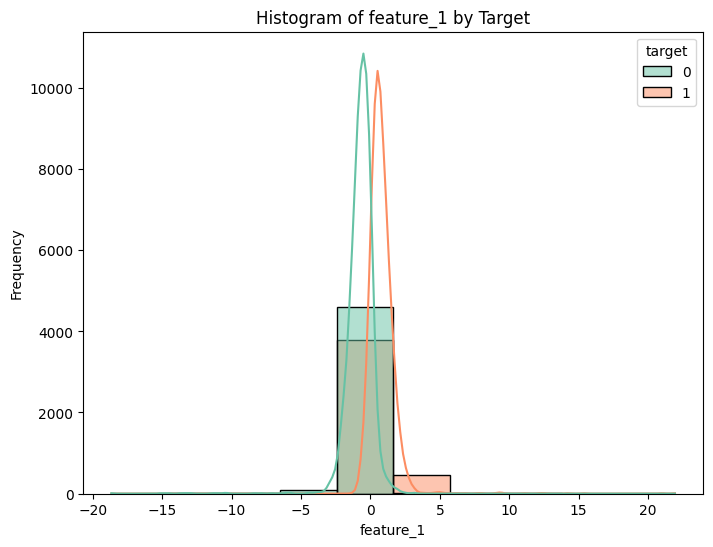

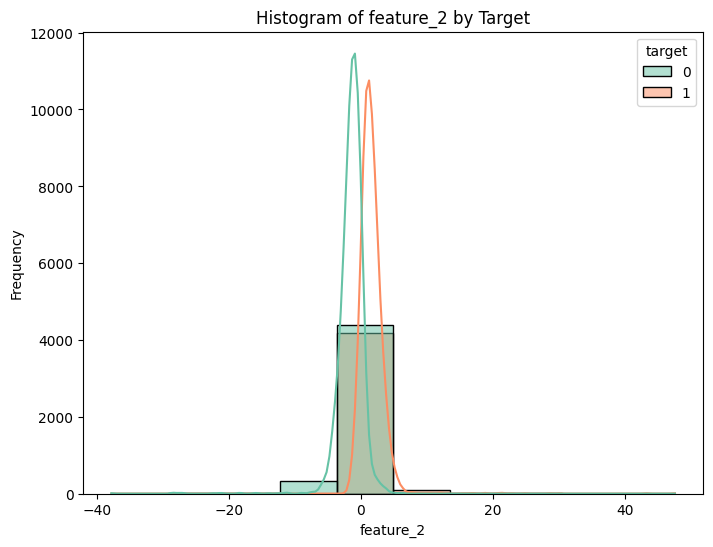

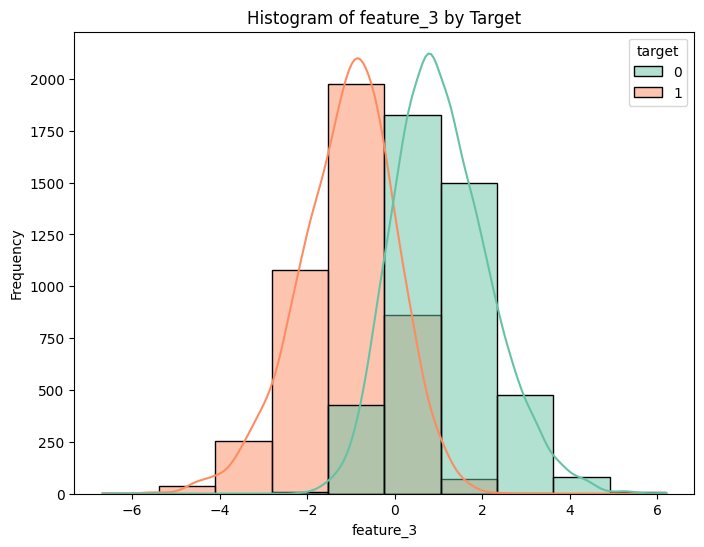

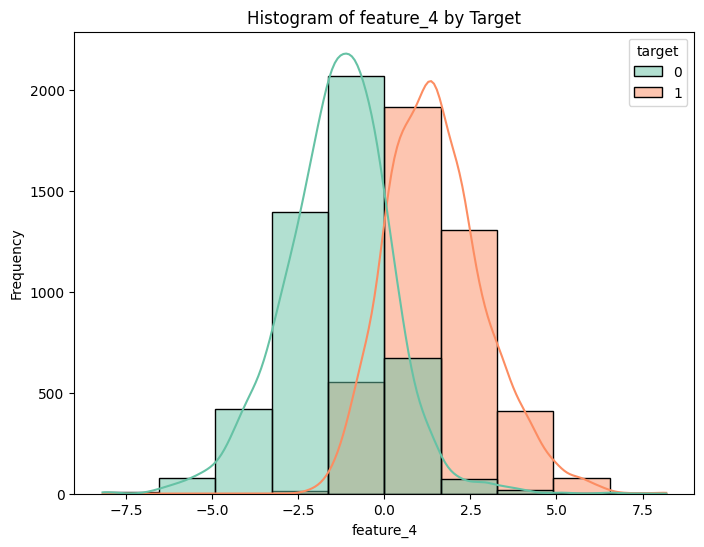

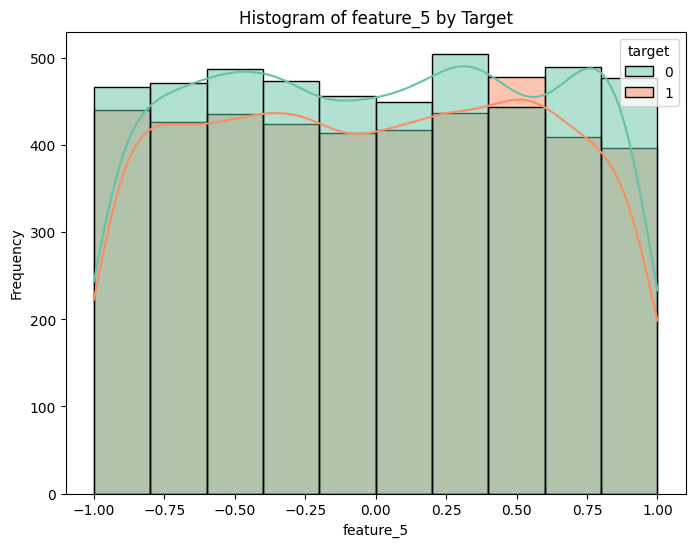

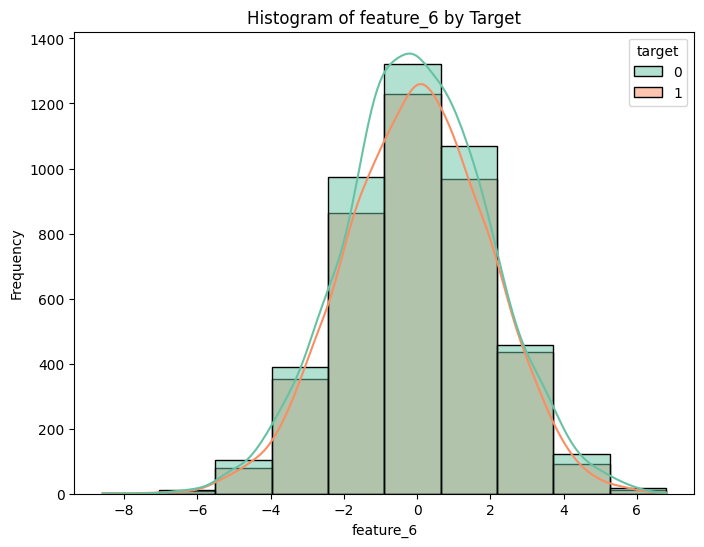

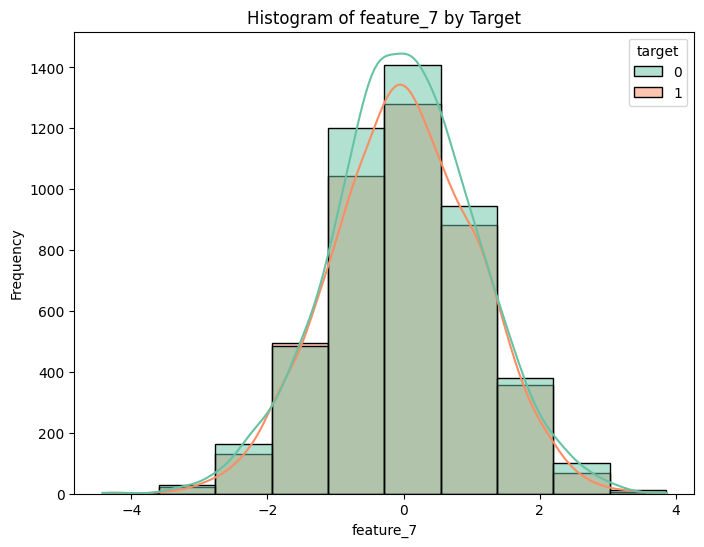

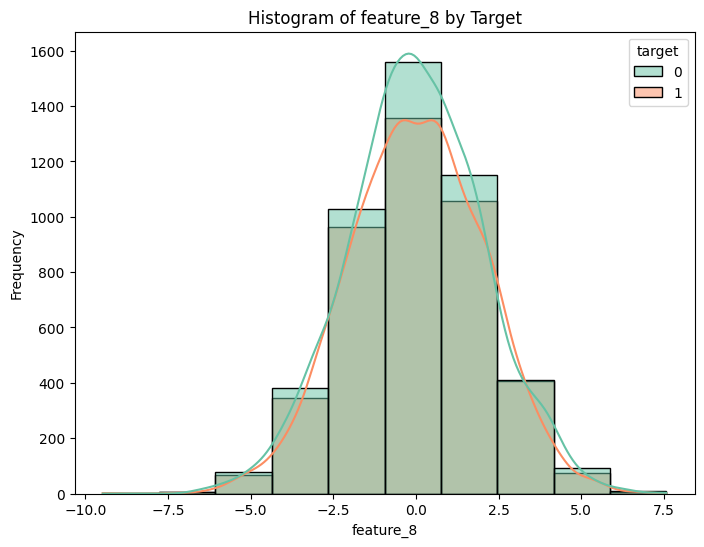

In [9]:
features = ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8']

# Loop through each feature and create a separate histogram for it
for feature in features:
    plt.figure(figsize=(8, 6))  # Set the figure size for each plot
    sns.histplot(df, x=feature, hue="target", kde=True, palette="Set2", bins=10)
    plt.title(f"Histogram of {feature} by Target")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

In [10]:
X = df.values
print(df)


      feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0      0.496714   1.146509  -0.648521   0.833005   0.784920  -2.209437   
1     -0.138264  -0.061846        NaN   0.403768   0.704674  -2.498565   
2      0.647689   1.395115  -0.764126   1.708266  -0.250029   1.956259   
3      1.523030   2.657560  -2.461653   2.649051   0.882201   3.445638   
4     -0.234153  -0.499391   0.576097  -0.441656   0.610601   0.211425   
...         ...        ...        ...        ...        ...        ...   
8995   0.101630   0.400250        NaN  -0.019412  -0.063150   0.077627   
8996   1.167218   2.177774  -1.716067   1.994835   0.350043  -0.544915   
8997   1.588447   3.333945  -2.615488   3.476880  -0.933276   2.027658   
8998  -0.684987  -1.599835   1.063341  -1.252109  -0.724001   2.228943   
8999   0.801182   1.808647  -1.383917   1.841776   0.702840  -0.339918   

      feature_7  feature_8     category_1 category_2  target  
0     -1.300105  -2.242241  Above Average   Regi

# Data preprocessing

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

X = df.values
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(X[:,0:8])
X[:,0:8] = imputer.transform(X[:,0:8])
df = pd.DataFrame(X)
encoder = LabelEncoder()
df[8] = encoder.fit_transform(df[8])
df[9] = encoder.fit_transform(df[9])
scaleMinMax = MinMaxScaler(feature_range=(0,1))
numerical_columns = [0,1,2,3,4,5,6,7]
df[numerical_columns] = scaleMinMax.fit_transform(df[numerical_columns])
df.rename(columns={0: 'feature_1', 1: 'feature_2',2: 'feature_3', 3: 'feature_4'
,4: 'feature_5', 5: 'feature_6', 6: 'feature_7', 7: 'feature_8',8: 'category_1',9: 'category_2',10: 'target'}, inplace=True)
print(df.head(20))

    feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0    0.471974   0.456366   0.468034   0.550892   0.892487   0.414520   
1    0.456335   0.442226   0.518638   0.524686   0.852358   0.395739   
2    0.475693   0.459275   0.459059   0.604330   0.374936   0.685116   
3    0.497253   0.474048   0.327260   0.661768   0.941135   0.781863   
4    0.453973   0.437106   0.563115   0.473070   0.805315   0.571775   
5    0.453973   0.434765   0.539270   0.457128   0.851162   0.536450   
6    0.498637   0.479435   0.294381   0.702286   0.932387   0.690899   
7    0.478642   0.463204   0.406127   0.586185   0.937035   0.601870   
8    0.448177   0.432676   0.563037   0.467498   0.239996   0.557622   
9    0.473104   0.458334   0.487067   0.588938   0.127602   0.687135   
10   0.448326   0.432904   0.593347   0.441197   0.690872   0.384355   
11   0.448269   0.429011   0.610450   0.415400   0.563192   0.556518   
12   0.465700   0.442713   0.518638   0.519340   0.327370   0.50

In [12]:
def detect_outliers(feature):
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# Detect outliers for all numeric features
numeric_features = df.select_dtypes(include=['float64', 'int64']).columns
outlier_bounds = {}

for feature in numeric_features:
    lower, upper = detect_outliers(feature)
    outlier_bounds[feature] = (lower, upper)
    print(f"{feature}: Lower Bound = {lower}, Upper Bound = {upper}")


feature_1: Lower Bound = 0.3927220976942696, Upper Bound = 0.5267691875837588
feature_2: Lower Bound = 0.3782747410580039, Upper Bound = 0.5075964862389142
feature_3: Lower Bound = 0.21618968478274336, Upper Bound = 0.8205253548919735
feature_4: Lower Bound = 0.15868223082855482, Upper Bound = 0.84103359582867
feature_5: Lower Bound = -0.5011997760838616, Upper Bound = 1.4983327394936015
feature_6: Lower Bound = 0.23664490562589616, Upper Bound = 0.8799548262741677
feature_7: Lower Bound = 0.19012749997269768, Upper Bound = 0.8819675454863362
feature_8: Lower Bound = 0.23348805182214546, Upper Bound = 0.8807695907232042
category_1: Lower Bound = -2.0, Upper Bound = 6.0
category_2: Lower Bound = -1.5, Upper Bound = 2.5


# Exploratory Data Analysis (EDA)

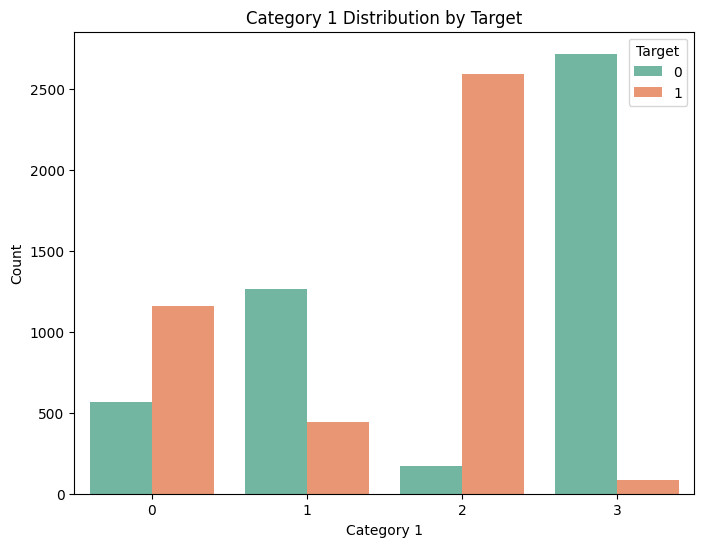

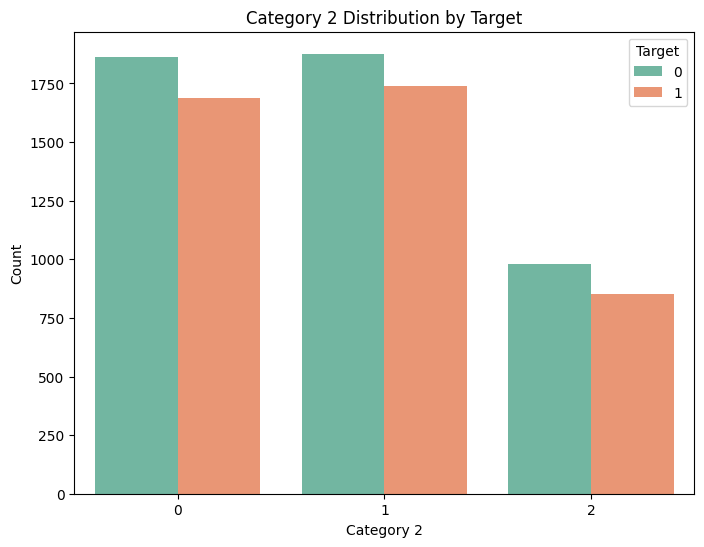

In [13]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='category_1', hue='target', palette="Set2")
plt.title("Category 1 Distribution by Target")
plt.xlabel("Category 1")
plt.ylabel("Count")
plt.legend(title="Target")
plt.show()

# Bar chart for category_2 grouped by target
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='category_2', hue='target', palette="Set2")
plt.title("Category 2 Distribution by Target")
plt.xlabel("Category 2")
plt.ylabel("Count")
plt.legend(title="Target")
plt.show()

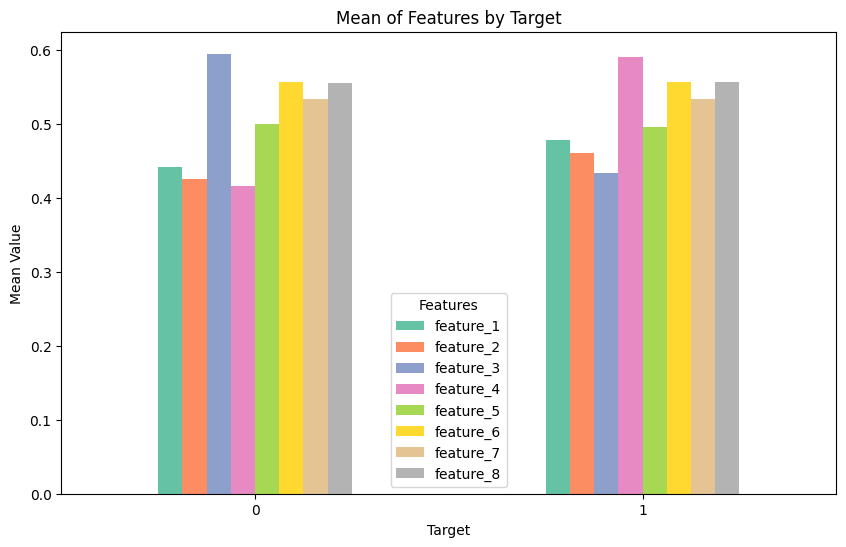

In [14]:
features = ['feature_1', 'feature_2', 'feature_3', 'feature_4','feature_5','feature_6','feature_7','feature_8']
mean_features = df.groupby('target')[features].mean()

mean_features.plot(kind='bar', figsize=(10, 6), colormap='Set2')
plt.title("Mean of Features by Target")
plt.xlabel("Target")
plt.ylabel("Mean Value")
plt.xticks(rotation=0)
plt.legend(title="Features")
plt.show()

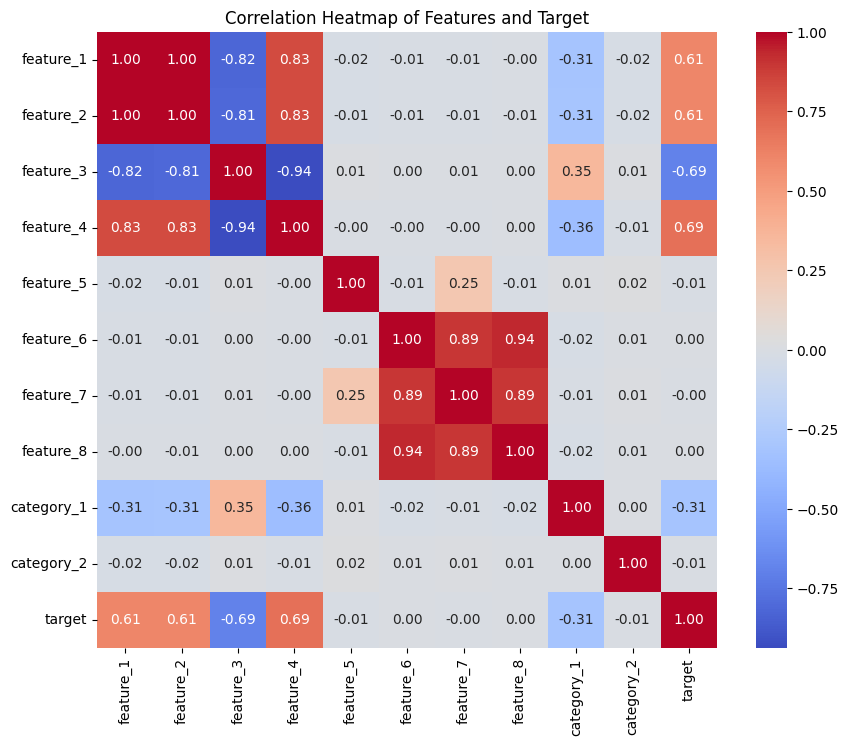

In [15]:

# Heatmap: Correlation matrix of numerical features and target
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap of Features and Target')
plt.show()

In [16]:
from sklearn.feature_selection import chi2
from scipy.stats import ttest_ind
X = df.drop('target', axis=1)
y = df['target']
y = pd.to_numeric(y)
chi_scores = chi2(X, y)
print(X)
print("Chi-square scores:", chi_scores[0])
print("P-values:", chi_scores[1])
# T-tests (assumes binary classification)
group0 = X[y == 0]
group1 = X[y == 1]

t_stats = []
t_p_values = []

for col in X.columns:
    t_stat, p_val = ttest_ind(group0[col], group1[col], equal_var=False)  # Welch's t-test
    t_stats.append(t_stat)
    t_p_values.append(p_val)

# Display results as a DataFrame
t_test_results = pd.DataFrame({
    'Feature': X.columns,
    'T-statistic': t_stats,
    'P-value': t_p_values
})

print("\nT-test results:")
print(t_test_results.sort_values(by='P-value'))

      feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0      0.471974   0.456366   0.468034   0.550892   0.892487   0.414520   
1      0.456335   0.442226   0.518638   0.524686   0.852358   0.395739   
2      0.475693   0.459275   0.459059   0.604330   0.374936   0.685116   
3      0.497253   0.474048   0.327260   0.661768   0.941135   0.781863   
4      0.453973   0.437106   0.563115   0.473070   0.805315   0.571775   
...         ...        ...        ...        ...        ...        ...   
8995   0.462243   0.447633   0.518638   0.498849   0.468389   0.563084   
8996   0.488489   0.468434   0.385149   0.621826   0.675016   0.522644   
8997   0.498865   0.481963   0.315316   0.712309   0.033262   0.689754   
8998   0.442868   0.424228   0.600946   0.423589   0.137915   0.702829   
8999   0.479474   0.464114   0.410937   0.612481   0.851441   0.535961   

      feature_7  feature_8  category_1  category_2  
0      0.377096   0.424269           0           2  
1    

# Feature engineering

In [17]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Assuming `df` is your original DataFrame
X = df[['feature_1', 'feature_2']]

# Create polynomial features (degree 2 includes interaction terms)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_interactions = poly.fit_transform(X)

# Get feature names
feature_names = poly.get_feature_names_out(input_features=['feature_1', 'feature_2'])

# Scale the interaction terms
scaler = StandardScaler()
X_interactions_scaled = scaler.fit_transform(X_interactions)

# Convert scaled interaction terms to DataFrame
interaction_df = pd.DataFrame(X_interactions_scaled, columns=feature_names)
combined_df = df
# Drop the original columns from the dataset
combined_df = combined_df.drop(columns=['feature_1', 'feature_2'])

# Add the interaction terms to the dataset
# If a single combined column name is desired:
combined_df['combined_features1_2'] = interaction_df.sum(axis=1)

# Print the updated DataFrame
print(combined_df.head(10))
Featured_df = combined_df
print(Featured_df.head(10))

   feature_3  feature_4  feature_5  feature_6  feature_7  feature_8  \
0   0.468034   0.550892   0.892487   0.414520   0.377096   0.424269   
1   0.518638   0.524686   0.852358   0.395739   0.372371   0.441863   
2   0.459059   0.604330   0.374936   0.685116   0.677881   0.643995   
3   0.327260   0.661768   0.941135   0.781863   0.790288   0.755769   
4   0.563115   0.473070   0.805315   0.571775   0.647145   0.532248   
5   0.539270   0.457128   0.851162   0.536450   0.588952   0.507302   
6   0.294381   0.702286   0.932387   0.690899   0.719104   0.659733   
7   0.406127   0.586185   0.937035   0.601870   0.632309   0.643190   
8   0.563037   0.467498   0.239996   0.557622   0.171429   0.275408   
9   0.487067   0.588938   0.127602   0.687135   0.586296   0.749924   

   category_1  category_2 target  combined_features1_2  
0           0           2      1              1.238610  
1           1           0      0             -0.235096  
2           2           2      1              1

In [20]:

domain_knowledge_df = Featured_df
# Create a new feature 'total_service_usage' as the sum of numerical features
numerical_features = ['feature_3',
                      'feature_4', 'feature_5', 'feature_6',
                      'feature_7', 'feature_8','combined_features1_2']

# Calculate total service usage
domain_knowledge_df['total_service_usage'] = domain_knowledge_df[numerical_features].sum(axis=1, skipna=True)

# Display the updated dataset with the new feature
domain_knowledge_df[['total_service_usage']].head()
# Additional derived features using numerical columns

# Average service usage
domain_knowledge_df['avg_service_usage'] = domain_knowledge_df[numerical_features].mean(axis=1, skipna=True)

# Maximum and minimum service usage
domain_knowledge_df['max_service_usage'] = domain_knowledge_df[numerical_features].max(axis=1, skipna=True)
domain_knowledge_df['min_service_usage'] = domain_knowledge_df[numerical_features].min(axis=1, skipna=True)

# Range of service usage (max - min)
domain_knowledge_df['usage_range'] = domain_knowledge_df['max_service_usage'] - df['min_service_usage']

# High usage flag: 1 if total_service_usage > (mean + std deviation), else 0
threshold = domain_knowledge_df['total_service_usage'].mean() + domain_knowledge_df['total_service_usage'].std()
domain_knowledge_df['high_usage_flag'] = (domain_knowledge_df['total_service_usage'] > threshold).astype(int)

# Display the newly added features
# domain_knowledge_df[['avg_service_usage', 'max_service_usage', 'min_service_usage',
#     'usage_range', 'high_usage_flag']].head()

domain_knowledge_df = domain_knowledge_df[['avg_service_usage', 'max_service_usage', 'min_service_usage',
    'usage_range', 'high_usage_flag']]
domain_knowledge_df.head()

print(df.head(4))


KeyError: 'min_service_usage'

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
# Separate features (X) and target variable (y)
X = df.drop(columns=['target','total_service_usage','avg_service_usage','max_service_usage','min_service_usage','usage_range','high_usage_flag'])
y = df['target']
y = y.astype(int)  # Convert to integer labels
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train = y_train.astype(int)  # Convert to integer labels
y_test = y_test.astype(int)
# Initialize and train the Logistic Regression model
logistic_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = logistic_model.predict(X_test)
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary')
recall = recall_score(y_test, y_pred, average='binary')
classification_report_output = classification_report(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='binary')
roc_auc = roc_auc_score(y_test, y_pred_proba)
# Display evaluation metrics
# accuracy, precision, recall, classification_report_output
print("Accuracy",accuracy)
print("precision",precision)
print("recall",recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)

Accuracy 0.8555555555555555
precision 0.8435689455388181
recall 0.8534583821805393
F1-score: 0.8484848484848485
ROC-AUC: 0.9323055097172412


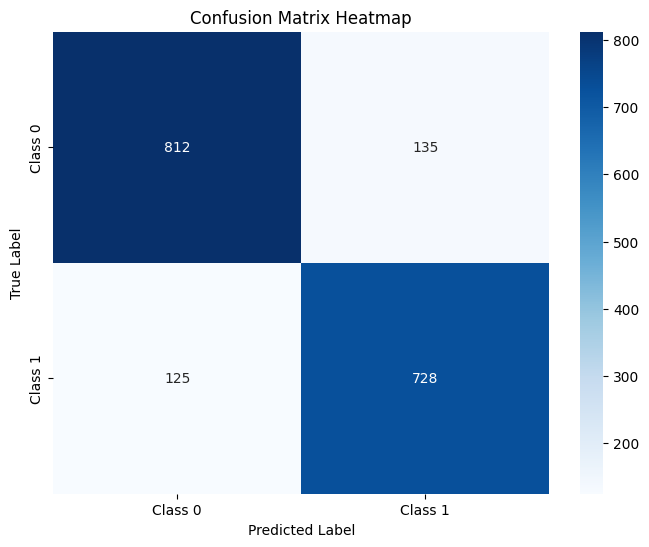

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

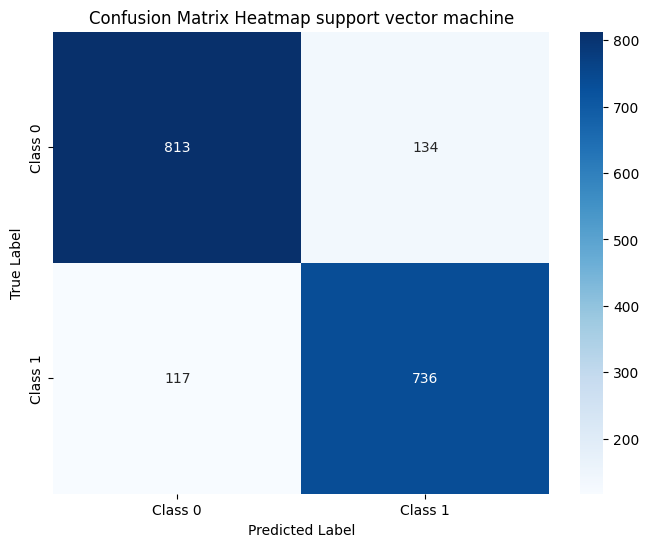

📊 Evaluation Metrics
Accuracy: 0.8605555555555555
Precision: 0.8459770114942529
Recall: 0.8628370457209847
F1 Score: 0.8543238537434706
ROC AUC Score: 0.9238454006048595


In [19]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC  # Support Vector Classifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = SVC(kernel='rbf', C=1.0, gamma='scale',probability=True)  # C = regularization
model.fit(X_train, y_train)
# 5. Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for ROC AUC
# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap support vector machine')
plt.show()
# 6. Evaluate the model
print("📊 Evaluation Metrics")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))




## Modeling

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
import joblib

# Initialize the models
decision_tree_model = DecisionTreeClassifier(random_state=42)
random_forest_model = RandomForestClassifier(random_state=42)

# Train and predict with Decision Tree
decision_tree_model.fit(X_train, y_train)
y_pred_tree = decision_tree_model.predict(X_test)
y_proba_tree = decision_tree_model.predict_proba(X_test)[:, 1]  # for ROC-AUC

# Train and predict with Random Forest
random_forest_model.fit(X_train, y_train)
y_pred_forest = random_forest_model.predict(X_test)
y_proba_forest = random_forest_model.predict_proba(X_test)[:, 1]  # for ROC-AUC

# Evaluate Decision Tree
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree, average='binary')
recall_tree = recall_score(y_test, y_pred_tree, average='binary')
f1_tree = f1_score(y_test, y_pred_tree, average='binary')
roc_auc_tree = roc_auc_score(y_test, y_proba_tree)
classification_report_tree = classification_report(y_test, y_pred_tree)

print("Decision Tree Metrics:")
print("Accuracy:", accuracy_tree)
print("Precision:", precision_tree)
print("Recall:", recall_tree)
print("F1-score:", f1_tree)
print("ROC-AUC:", roc_auc_tree)
print("\nClassification Report:\n", classification_report_tree)

# Evaluate Random Forest
accuracy_forest = accuracy_score(y_test, y_pred_forest)
precision_forest = precision_score(y_test, y_pred_forest, average='binary')
recall_forest = recall_score(y_test, y_pred_forest, average='binary')
f1_forest = f1_score(y_test, y_pred_forest, average='binary')
roc_auc_forest = roc_auc_score(y_test, y_proba_forest)
classification_report_forest = classification_report(y_test, y_pred_forest)

print("Random Forest Metrics:")
print("Accuracy:", accuracy_forest)
print("Precision:", precision_forest)
print("Recall:", recall_forest)
print("F1-score:", f1_forest)
print("ROC-AUC:", roc_auc_forest)
print("\nClassification Report:\n", classification_report_forest)


Decision Tree Metrics:
Accuracy: 0.8344444444444444
Precision: 0.8268551236749117
Recall: 0.8229777256740914
F1-score: 0.8249118683901293
ROC-AUC: 0.8338753464695694

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84       947
           1       0.83      0.82      0.82       853

    accuracy                           0.83      1800
   macro avg       0.83      0.83      0.83      1800
weighted avg       0.83      0.83      0.83      1800

Random Forest Metrics:
Accuracy: 0.8833333333333333
Precision: 0.8915956151035322
Recall: 0.8581477139507621
F1-score: 0.8745519713261649
ROC-AUC: 0.9539794327988304

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.89       947
           1       0.89      0.86      0.87       853

    accuracy                           0.88      1800
   macro avg       0.88      0.88      0.88      1800
weighted avg       

# Gradient Boosting Model

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Initialize the Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]  # Probabilities for ROC-AUC

# Evaluate the model
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb, average='binary')
recall_gb = recall_score(y_test, y_pred_gb, average='binary')
f1_gb = f1_score(y_test, y_pred_gb, average='binary')
roc_auc_gb = roc_auc_score(y_test, y_proba_gb)
classification_report_gb = classification_report(y_test, y_pred_gb)

# Print results
print("Gradient Boosting Metrics:")
print("Accuracy:", accuracy_gb)
print("Precision:", precision_gb)
print("Recall:", recall_gb)
print("F1-score:", f1_gb)
print("ROC-AUC:", roc_auc_gb)

Gradient Boosting Metrics:
Accuracy: 0.8822222222222222
Precision: 0.8951911220715166
Recall: 0.8511137162954279
F1-score: 0.8725961538461539
ROC-AUC: 0.9575174766740406


In [ ]:
from xgboost import XGBClassifier
import joblib
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Initialize XGBoost model
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)


# Train the model
xgb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]  # For ROC-AUC

# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, average='binary')
recall_xgb = recall_score(y_test, y_pred_xgb, average='binary')
f1_xgb = f1_score(y_test, y_pred_xgb, average='binary')
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
joblib.dump(xgb_model, 'xgb_model.pkl')
# Print results
print("XGBoost Metrics:")
print("Accuracy:", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall:", recall_xgb)
print("F1-score:", f1_xgb)
print("ROC-AUC:", roc_auc_xgb)


XGBoost Metrics:
Accuracy: 0.8716666666666667
Precision: 0.8811274509803921
Recall: 0.8429073856975381
F1-score: 0.8615937687237867
ROC-AUC: 0.949292576916554


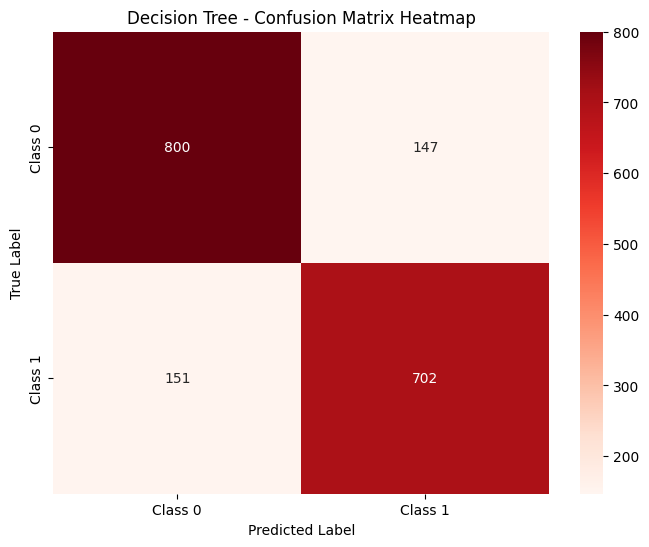

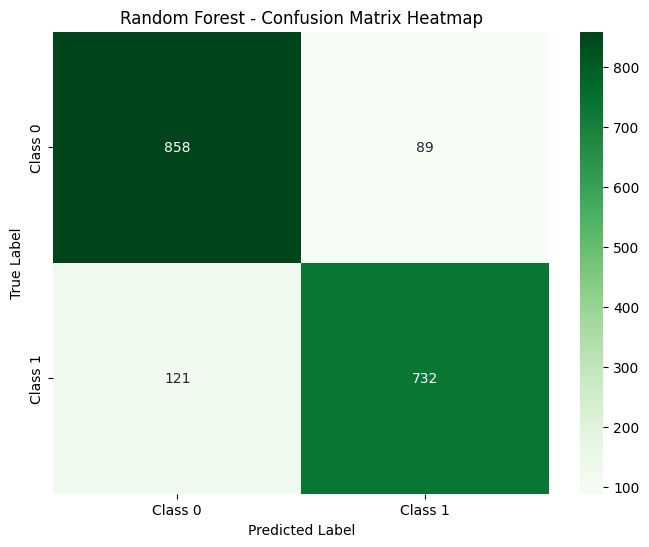

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix for Decision Tree
conf_matrix_tree = confusion_matrix(y_test, y_pred_tree)

# Confusion matrix for Random Forest
conf_matrix_forest = confusion_matrix(y_test, y_pred_forest)

# Plot Decision Tree heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_tree, annot=True, fmt='d', cmap='Reds', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Decision Tree - Confusion Matrix Heatmap')
plt.show()

# Plot Random Forest heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_forest, annot=True, fmt='d', cmap='Greens', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest - Confusion Matrix Heatmap')
plt.show()

## **Ensemble model**

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
log_model = LogisticRegression(max_iter=1000)
rf_model = RandomForestClassifier(n_estimators=50)
dt_model = DecisionTreeClassifier()


voting_ensemble = VotingClassifier(
    estimators=[
        ('logistic', log_model),
        ('random_forest', rf_model),
        ('decision_tree', dt_model)
    ],
    voting='hard'
)

# 5. Train the ensemble model
voting_ensemble.fit(X_train, y_train)

# 6. Evaluate the model
y_pred = voting_ensemble.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Voting Ensemble Accuracy: {accuracy:.2f}')

Voting Ensemble Accuracy: 0.88


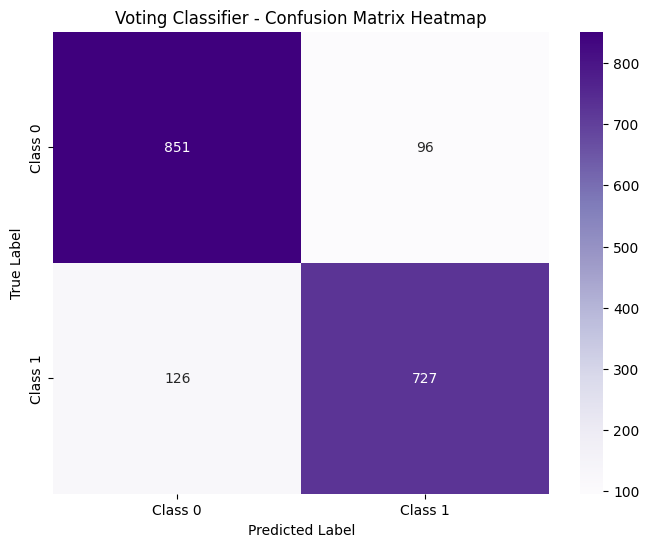

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix for the ensemble model
conf_matrix_ensemble = confusion_matrix(y_test, y_pred)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_ensemble, annot=True, fmt='d', cmap='Purples', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Voting Classifier - Confusion Matrix Heatmap')
plt.show()

# Perform cross-validation to ensure robust performance estimates.

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# Initialize the models
logistic_model = LogisticRegression(random_state=42)
gradient_boosting_model = GradientBoostingClassifier(random_state=42)
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)

# Perform cross-validation for Decision Tree
cv_scores_tree = cross_val_score(decision_tree_model, X, y, cv=5, scoring='accuracy')
mean_cv_score_tree = cv_scores_tree.mean()

# Perform cross-validation for Random Forest
cv_scores_forest = cross_val_score(random_forest_model, X, y, cv=5, scoring='accuracy')
mean_cv_score_forest = cv_scores_forest.mean()

# Perform cross-validation for Logistic Regression
cv_scores_logistic = cross_val_score(logistic_model, X, y, cv=5, scoring='accuracy')
mean_cv_score_logistic = cv_scores_logistic.mean()

# Perform cross-validation for Gradient Boosting
cv_scores_gb = cross_val_score(gradient_boosting_model, X, y, cv=5, scoring='accuracy')
mean_cv_score_gb = cv_scores_gb.mean()

# Perform cross-validation for XGBoost
cv_scores_xgb = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')
mean_cv_score_xgb = cv_scores_xgb.mean()

# Display cross-validation results
results = {
    "Decision Tree": {
        "Cross-Validation Scores": cv_scores_tree.tolist(),
        "Mean Accuracy": mean_cv_score_tree
    },
    "Random Forest": {
        "Cross-Validation Scores": cv_scores_forest.tolist(),
        "Mean Accuracy": mean_cv_score_forest
    },
    "Logistic Regression": {
        "Cross-Validation Scores": cv_scores_logistic.tolist(),
        "Mean Accuracy": mean_cv_score_logistic
    },
    "Gradient Boosting": {
        "Cross-Validation Scores": cv_scores_gb.tolist(),
        "Mean Accuracy": mean_cv_score_gb
    },
    "XGBoost": {
        "Cross-Validation Scores": cv_scores_xgb.tolist(),
        "Mean Accuracy": mean_cv_score_xgb
    }
}

# Output the results
print(results)

{'Decision Tree': {'Cross-Validation Scores': [0.8316666666666667, 0.8533333333333334, 0.8372222222222222, 0.8388888888888889, 0.8444444444444444], 'Mean Accuracy': np.float64(0.8411111111111111)}, 'Random Forest': {'Cross-Validation Scores': [0.8811111111111111, 0.8872222222222222, 0.8761111111111111, 0.8833333333333333, 0.895], 'Mean Accuracy': np.float64(0.8845555555555557)}, 'Logistic Regression': {'Cross-Validation Scores': [0.8455555555555555, 0.8533333333333334, 0.8472222222222222, 0.8527777777777777, 0.8688888888888889], 'Mean Accuracy': np.float64(0.8535555555555556)}, 'Gradient Boosting': {'Cross-Validation Scores': [0.8805555555555555, 0.8833333333333333, 0.8788888888888889, 0.8877777777777778, 0.8938888888888888], 'Mean Accuracy': np.float64(0.8848888888888891)}, 'XGBoost': {'Cross-Validation Scores': [0.8588888888888889, 0.8811111111111111, 0.86, 0.8755555555555555, 0.8822222222222222], 'Mean Accuracy': np.float64(0.8715555555555555)}}


# Model Tuning

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
# df = pd.read_csv('updated.csv')

# Display the first few rows to confirm data is loaded correctly
print(df.head())
# df.to_csv('updated2.csv')
# Display dataset structure
print(df.info())


   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0   0.471974   0.456366   0.468034   0.550892   0.892487   0.414520   
1   0.456335   0.442226   0.518638   0.524686   0.852358   0.395739   
2   0.475693   0.459275   0.459059   0.604330   0.374936   0.685116   
3   0.497253   0.474048   0.327260   0.661768   0.941135   0.781863   
4   0.453973   0.437106   0.563115   0.473070   0.805315   0.571775   

   feature_7  feature_8  category_1  category_2 target  total_service_usage  \
0   0.377096   0.424269           0           2      1             4.055639   
1   0.372371   0.441863           1           0      0             4.004215   
2   0.677881   0.643995           2           2      1             4.380284   
3   0.790288   0.755769           2           1      1             5.229385   
4   0.647145   0.532248           1           2      0             4.483746   

   avg_service_usage  max_service_usage  min_service_usage  usage_range  \
0           0.506955   

In [ ]:
# Split the dataset into features (X) and target (y)
X = df.drop(columns=['target'])  # Replace 'target' with the actual target column name
y = df['target']

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train)
y_train = y_train.astype(int)  # Convert to integer labels
y_test = y_test.astype(int)
# Confirm the shape of the splits
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

      feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
6317   0.446712   0.429994   0.564575   0.407810   0.472373   0.582692   
740    0.414398   0.397961   0.702662   0.223386   0.265373   0.408877   
3781   0.451693   0.432112   0.532077   0.420956   0.958740   0.637781   
7850   0.509061   0.493871   0.250078   0.739995   0.557298   0.449054   
2963   0.433716   0.415905   0.658639   0.358635   0.550183   0.549548   
...         ...        ...        ...        ...        ...        ...   
5734   0.445600   0.429625   0.610027   0.415814   0.202161   0.695678   
5191   0.458723   0.442421   0.501084   0.509742   0.843542   0.763603   
5390   0.442513   0.423989   0.636848   0.411402   0.533395   0.509482   
860    0.464738   0.449116   0.493954   0.504770   0.334296   0.711480   
7270   0.417433   0.402598   0.713370   0.292690   0.599830   0.441564   

      feature_7  feature_8  category_1  category_2  total_service_usage  \
6317   0.616308   0.549408          

In [ ]:
# Define the Random Forest model
model = RandomForestClassifier(random_state=42)

# Define the parameter grid for tuning
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'max_depth': [5, 10, 20, None],  # Maximum depth of each tree
    'min_samples_split': [2, 5, 10],  # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4]  # Minimum samples required at a leaf node
}


In [ ]:
import joblib
# Perform Grid Search with cross-validation
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    verbose=2,  # Print progress
    n_jobs=-1  # Use all available CPU cores
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Assign the best estimator (model with best parameters) to a variable
best_model = grid_search.best_estimator_
joblib.dump(best_model, 'best_random_forest_model.joblib')

# Display the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

NameError: name 'GridSearchCV' is not defined

NameError: name 'best_model' is not defined

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Initialize the logistic regression model
logistic_regression_model  = LogisticRegression(random_state=42, max_iter=5000)

# Define the hyperparameter grid for tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength (Inverse)
    'penalty': ['l1', 'l2'],       # Regularization type
    'solver': ['liblinear', 'saga']  # Solver (needed for l1 and l2)
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=logistic_regression_model,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Assign the best estimator to a variable
best_model = grid_search.best_estimator_

# Display the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.8563888888888889


## Compare the performance of tuned models against default models.

In [ ]:
# Train the Default Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib
# Initialize and train the default model
default_model = RandomForestClassifier(random_state=42)
default_model.fit(X_train, y_train)

# Evaluate on the test set
default_y_pred = default_model.predict(X_test)
default_accuracy = accuracy_score(y_test, default_y_pred)

print("Default Model Test Accuracy:", default_accuracy)
print("Default Model Classification Report:\n", classification_report(y_test, default_y_pred))
# Train and Evaluate the Tuned Model
# Use the best estimator from GridSearchCV
best_model.fit(X_train, y_train)

# Evaluate on the test set
tuned_y_pred = best_model.predict(X_test)
tuned_accuracy = accuracy_score(y_test, tuned_y_pred)

print("Tuned Model Test Accuracy:", tuned_accuracy)
print("Tuned Model Classification Report:\n", classification_report(y_test, tuned_y_pred))
# Compare the performance of the two models based on key metrics:
print(f"Default Model Accuracy: {default_accuracy:.4f}")
print(f"Tuned Model Accuracy: {tuned_accuracy:.4f}")

if tuned_accuracy > default_accuracy:
    print("The tuned model outperforms the default model.")
else:
    print("The default model performs better than or as well as the tuned model.")

Default Model Test Accuracy: 0.8788888888888889
Default Model Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.90      0.89       947
           1       0.89      0.85      0.87       853

    accuracy                           0.88      1800
   macro avg       0.88      0.88      0.88      1800
weighted avg       0.88      0.88      0.88      1800

Tuned Model Test Accuracy: 0.8527777777777777
Tuned Model Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86       947
           1       0.85      0.84      0.84       853

    accuracy                           0.85      1800
   macro avg       0.85      0.85      0.85      1800
weighted avg       0.85      0.85      0.85      1800

Default Model Accuracy: 0.8789
Tuned Model Accuracy: 0.8528
The default model performs better than or as well as the tuned model.


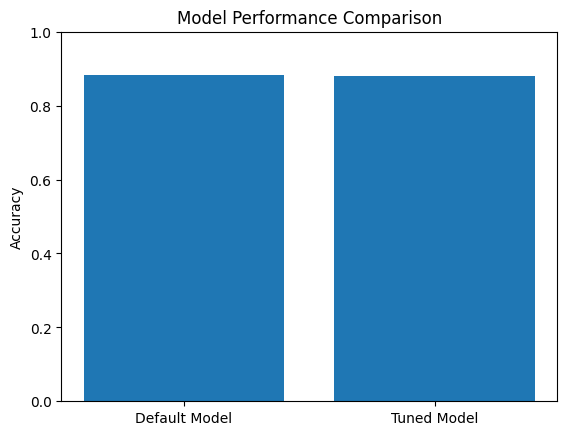

In [ ]:
import matplotlib.pyplot as plt

# Metrics for comparison
models = ['Default Model', 'Tuned Model']
accuracies = [default_accuracy, tuned_accuracy]

# Plot
plt.bar(models, accuracies)
plt.title('Model Performance Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  # Accuracy ranges from 0 to 1
plt.show()

# Model Interpretation

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
# Train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
importances = model.feature_importances_
# Assuming X_train is a DataFrame
feature_names = X_train.columns
feature_importance = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

# Display the sorted feature importance
for feature, importance in feature_importance:
    print(f"{feature}: {importance:.4f}")

feature_2: 0.2395
feature_1: 0.2394
feature_3: 0.2177
feature_4: 0.1076
category_1: 0.0412
feature_5: 0.0393
feature_7: 0.0361
feature_6: 0.0349
feature_8: 0.0347
category_2: 0.0096


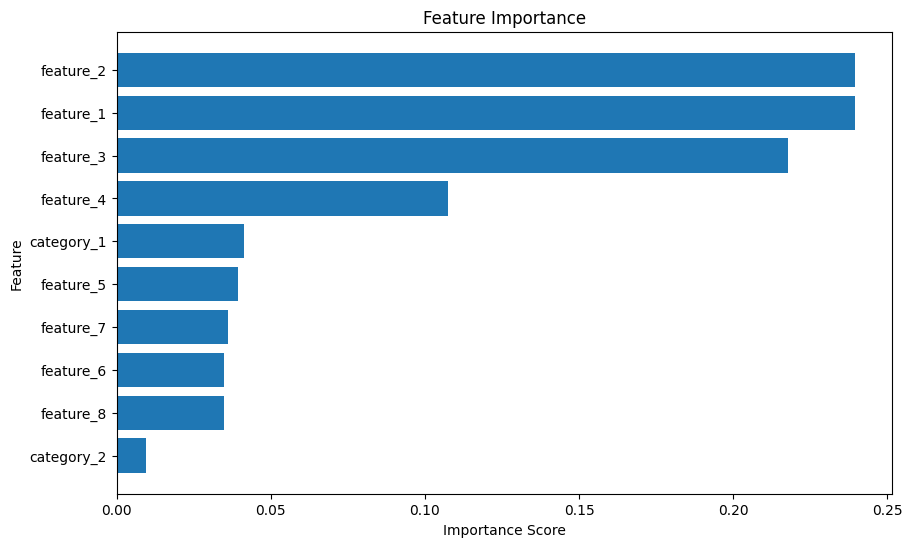

In [ ]:
# Convert to DataFrame for easy plotting
import pandas as pd
importance_df = pd.DataFrame(feature_importance, columns=["Feature", "Importance"])

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.gca().invert_yaxis()  # Invert y-axis for descending order
plt.show()

In [ ]:
top_features = importance_df.head(5)
print("Top Features:\n", top_features)

Top Features:
       Feature  Importance
0   feature_2    0.239505
1   feature_1    0.239403
2   feature_3    0.217655
3   feature_4    0.107567
4  category_1    0.041230


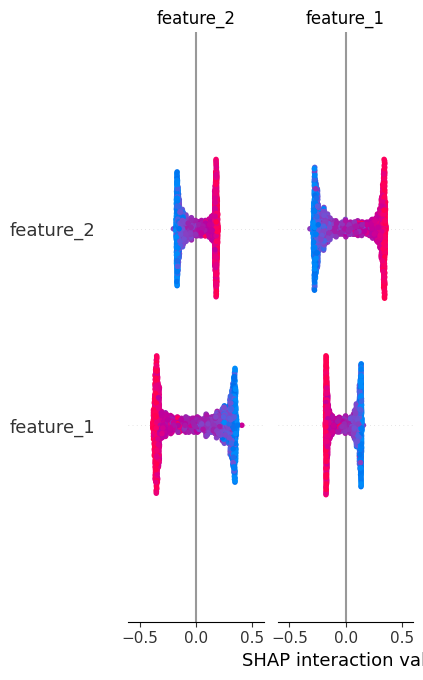

In [ ]:
from sklearn.inspection import permutation_importance

import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Visualize SHAP summary ssca
shap.summary_plot(shap_values, X_test)